# Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
# Set the visual style for the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [4]:
df = pd.read_csv('vaccinations_cleaned.csv')

# MODELING - PREDICTING FULL VACCINATIONS

- Here, we build a simple linear regression model to predict the number of fully vaccinated people based on the number of people with at least one dose.

## Feature Selection and Data Preparation

- We are interested in the relationship between these two variables:
- Independent Variable (X): 'people_vaccinated' (at least one dose)
- Dependent Variable (y): 'people_fully_vaccinated'

In [5]:
# For a more accurate model, we filter out rows where these values are zero.
model_df = df[(df['people_vaccinated'] > 0) & (df['people_fully_vaccinated'] > 0)].copy()

In [6]:
# Define our feature (X) and target (y)
# X needs to be a 2D array, so we use [['people_vaccinated']]
X = model_df[['people_vaccinated']] 
y = model_df['people_fully_vaccinated']

## Splitting Data into Training and Testing Sets

In [7]:
# We'll use 80% of the data for training the model and 20% for testing its performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into training ({len(X_train)} rows) and testing ({len(X_test)} rows) sets.")

Data split into training (60370 rows) and testing (15093 rows) sets.


## Training the Model

In [8]:
# Create an instance of the LinearRegression model
lr_model = LinearRegression()

In [11]:
# Fit the model to the training data
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# MODEL EVALUATION

In [12]:
# Make predictions on the test data
y_pred = lr_model.predict(X_test)

## Key Performance Metrics

In [13]:
# R-squared explains the proportion of variance in the target variable that can be explained by the independent variable.
r2_score = metrics.r2_score(y_test, y_pred)

In [14]:
# MAE, MSE, and RMSE are error metrics that tell us how far off our predictions are on average.
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [15]:
print(f"R-squared (R²): {r2_score:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

R-squared (R²): 0.9944
Mean Absolute Error (MAE): 17,514,580.04
Mean Squared Error (MSE): 3,268,388,519,391,462.50
Root Mean Squared Error (RMSE): 57,169,821.75


## Interpreting the Model's Coefficients

In [16]:
# The intercept is the value of y when X is 0.
# The slope (coefficient) tells us how much y is expected to increase for a one-unit increase in X.
intercept = lr_model.intercept_
slope = lr_model.coef_[0]

print(f"\nModel Intercept: {intercept:,.2f}")
print(f"Model Slope (Coefficient): {slope:.4f}")


Model Intercept: -5,754,536.51
Model Slope (Coefficient): 0.9050


# INSIGHTS AND VISUALIZATION

## Interpretation of Results

Model Insights:
- An R-squared value of 0.9944 means that approximately **99.44% of the variation** in the number of fully vaccinated people can be explained by the number of people who have received at least one vaccine dose. This indicates a very strong and reliable relationship.
- The slope of 0.9050 is particularly insightful. It suggests that for every **100 people** who receive their first vaccine dose, we can predict that approximately **90 people** will go on to become fully vaccinated.

## Visualization: Regression Plot

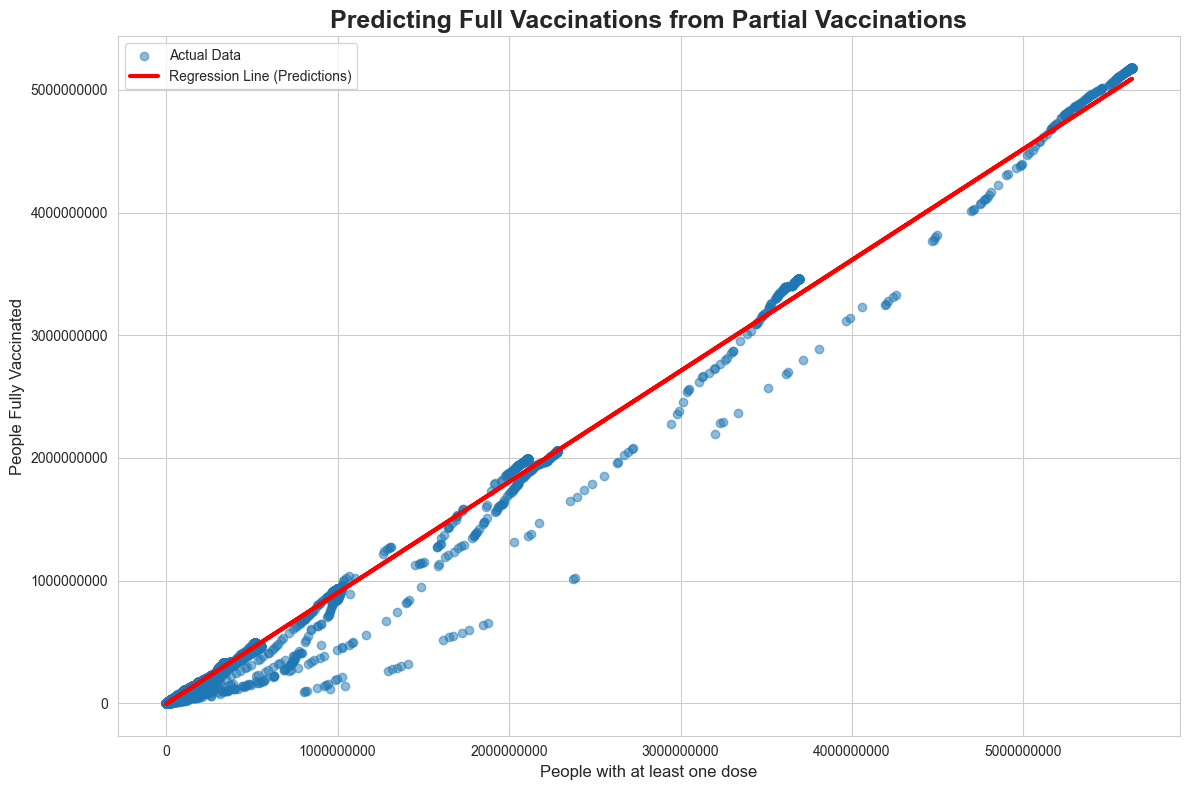

In [19]:
# We create a scatter plot of the actual test data and overlay our regression line (the model's predictions).
plt.figure(figsize=(12, 8))
# Scatter plot of the actual test values
plt.scatter(X_test, y_test, alpha=0.5, label='Actual Data')
# Line plot of the predicted values
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line (Predictions)')

plt.title('Predicting Full Vaccinations from Partial Vaccinations', fontsize=18, weight='bold')
plt.xlabel('People with at least one dose', fontsize=12)
plt.ylabel('People Fully Vaccinated', fontsize=12)
plt.legend()
plt.ticklabel_format(style='plain') # Disable scientific notation for clarity
plt.tight_layout()
plt.show()

- Visualization Conclusion: The plot above visually confirms our model's effectiveness. The red regression line fits the scattered data points very closely, demonstrating a strong linear relationship and the high predictive power of the model.